# EDA — Reconciliation-Focused Diagnostics

Every figure defends a specific modeling decision.  All computation imports from the module layer; no logic is re-implemented here.

**How to read this notebook:** Each section opens with a plain-English summary of what the figure shows and why it matters, followed by the technical detail.

**Decision map:**
| Figure | Decision defended |
|--------|-------------------|
| 1 — Base forecast incoherence | Motivates the task: base forecasts violate hierarchy identities |
| 2 — Heteroscedasticity | Relative forecast errors + per-day W_day rescaling |
| 3 — Volume growth | Per-day rescaling; a single absolute W would be dominated by peak days |
| 4 — Forecast bias | Disclose-not-fix: reconciliation cannot address per-day total bias |
| 5 — Autocorrelation (ACF) | Rolling-origin out-of-sample W estimation; SS lambda limitation |
| 6 — Covariance structure | Reliability ranking + key scatter pairs (sibling plots consolidated here) |
| **Appendix** 8 — Residual tails | Non-Gaussianity: known limitation, not a decision driver |
| **Appendix** 9 — Rolling stability | Supports using full-train C for future reconciliation |

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from data import SERIES, S, load, pred_array, actual_array
from covariance import relative_residuals, schafer_strimmer, effective_n_sensitivity
import eda

FIGURES_DIR = 'figures'
import os; os.makedirs(FIGURES_DIR, exist_ok=True)

In [2]:
train, future, gap_info = load()
print('Train rows:', gap_info['n_train'], '  Future rows:', gap_info['n_future'])
print('Max date gap in train:', gap_info['max_gap_days'], 'day(s)')
if gap_info['gap_dates']:
    print('Gap at:', [str(d.date()) for d in gap_info['gap_dates']])

# Fit relative covariance once on all train data
X_rel = relative_residuals(train, SERIES)
C, lam = schafer_strimmer(X_rel)
eff = effective_n_sensitivity(X_rel, lam, len(train))
print(f'\nSS lambda: {lam:.5f}')
print(f'n_eff (cross-product lag-1 rho={eff["rho_cross_product"]:.3f}): {eff["n_eff_cross_product"]:.0f}')
print(f'lambda inflated (cross-product): {eff["lambda_inflated_cp"]:.5f}')
print(f'n_eff (level-residual proxy, rho={eff["rho_level_residual"]:.3f}): {eff["n_eff_level_residual"]:.0f}')
print(f'lambda inflated (level-residual proxy): {eff["lambda_inflated_lv"]:.5f}')

Train rows: 1112   Future rows: 351
Max date gap in train: 2 day(s)
Gap at: ['2025-04-26']

SS lambda: 0.01358
n_eff (cross-product lag-1 rho=0.292): 938
lambda inflated (cross-product): 0.01610
n_eff (level-residual proxy, rho=0.522): 635
lambda inflated (level-residual proxy): 0.02378


## Figure 1: Base Forecast Incoherence

**Plain English:** The base model produces seven separate forecasts that should add up correctly — cohort forecasts should equal the total, leaves should equal their cohort parent.  They don't.  This figure shows how large the gap is, and reveals that the future period has ~170x larger incoherence than training.

**Decision defended:** Motivates the reconciliation task.  Training actuals are coherent (gaps < 4e-9); base forecasts are not.  Future gaps are ~170x larger than training gaps, consistent with the ~10x volume growth and a longer forecast horizon for the future block.

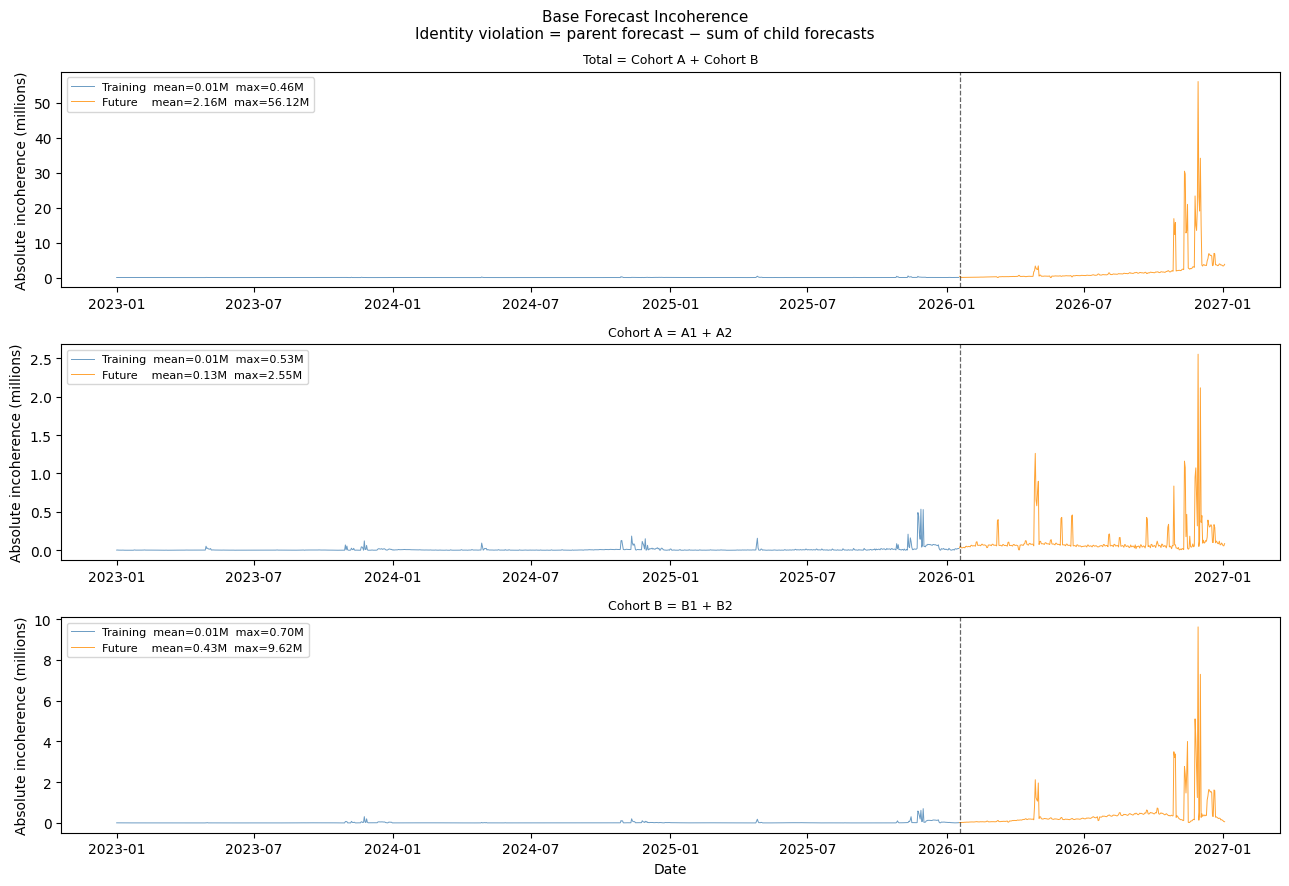

In [3]:
fig = eda.plot_incoherence(train, future, save_dir=FIGURES_DIR)
plt.show()

## Figure 2: Heteroscedasticity

**Plain English:** Big days have big errors; small days have small errors.  This means we cannot use a single fixed error size when building the covariance matrix.  We use *relative* errors (error divided by forecast level) to put all days on the same footing.

**Decision defended:** Relative forecast errors + per-day W_day = diag(pred) @ C @ diag(pred).  Three panels: (A) |error| vs level scatter for the Total series showing r(error, forecast)=0.62-0.73; (B) forecast-error standard deviation by volume quintile; (C) absolute vs relative forecast-error spread showing relative errors are more homoscedastic.

C:\Users\Deepan\Alo_yoga\retail_forecast\eda.py:229: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


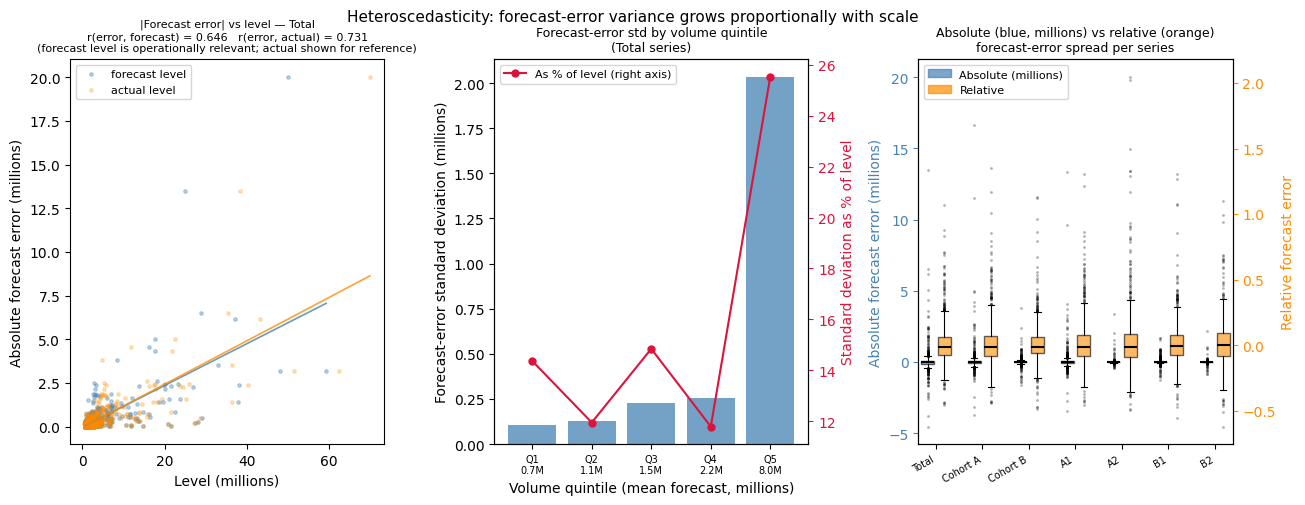

In [4]:
fig = eda.plot_heteroscedasticity(train, save_dir=FIGURES_DIR)
plt.show()

## Figure 3: Volume Growth and Seasonality

**Plain English:** Over three training years, volume grew ~10x.  November is always the peak month.  A covariance matrix estimated from low-volume data is useless for November, and vice versa.  The fix: estimate a scale-free relative covariance C once, then multiply by each day's forecast level to get a day-specific W.

**Decision defended:** Per-day W_day rescaling.  Total monthly mean grows ~10x over 3 years (~855k to ~8.4M mean daily).  November spike appears every year; April is also elevated.

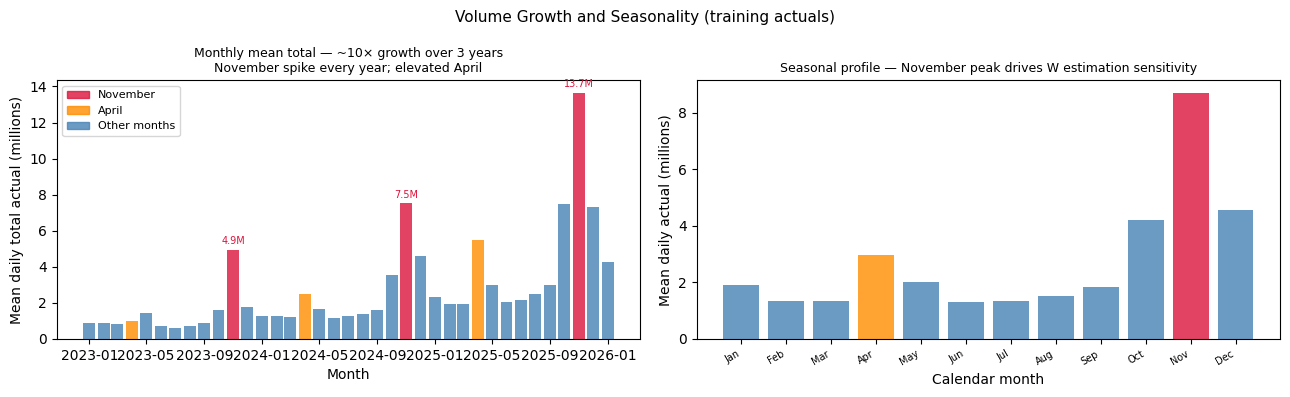

In [5]:
fig = eda.plot_volume_trend(train, save_dir=FIGURES_DIR)
plt.show()

## Figure 4: Forecast Bias

**Plain English:** The base model under-predicts on average, but over-predicts on more than half of all days.  The positive average error comes from a few very large under-shoots on the highest-volume days.  Reconciliation cannot fix this: it only redistributes a day's forecast across the hierarchy; it cannot change the day's total.

**Decision defended:** Disclose, do not attempt to fix via reconciliation.  Mean forecast error is 1.1%-4.1% of mean forecast level across all series.  Over-predicts on >50% of days; bias is driven by large under-shoots on high-volume days.

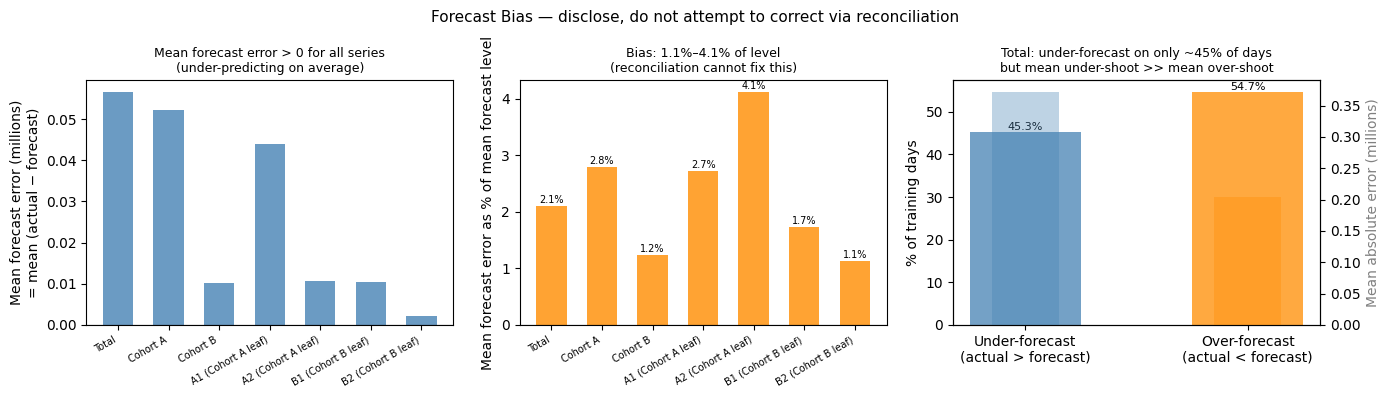

In [6]:
fig = eda.plot_bias(train, save_dir=FIGURES_DIR)
plt.show()

## Figure 5: Autocorrelation Function (ACF) of Forecast Errors

**Plain English:** If today's forecast was too high, tomorrow's probably will be too — forecast errors persist in runs of weeks.  This matters for two reasons: (1) the standard SS shrinkage formula assumes independent errors, so our lambda may be slightly too small; (2) we should estimate the error covariance from past data only at each rolling step, not a shuffled pool.

**Decision defended:** Rolling-origin out-of-sample W estimation in the backtest; acknowledging that the analytic SS lambda is derived under IID assumptions.  Lag-1 autocorrelation 0.34-0.56; longest same-sign error run up to 23 days.

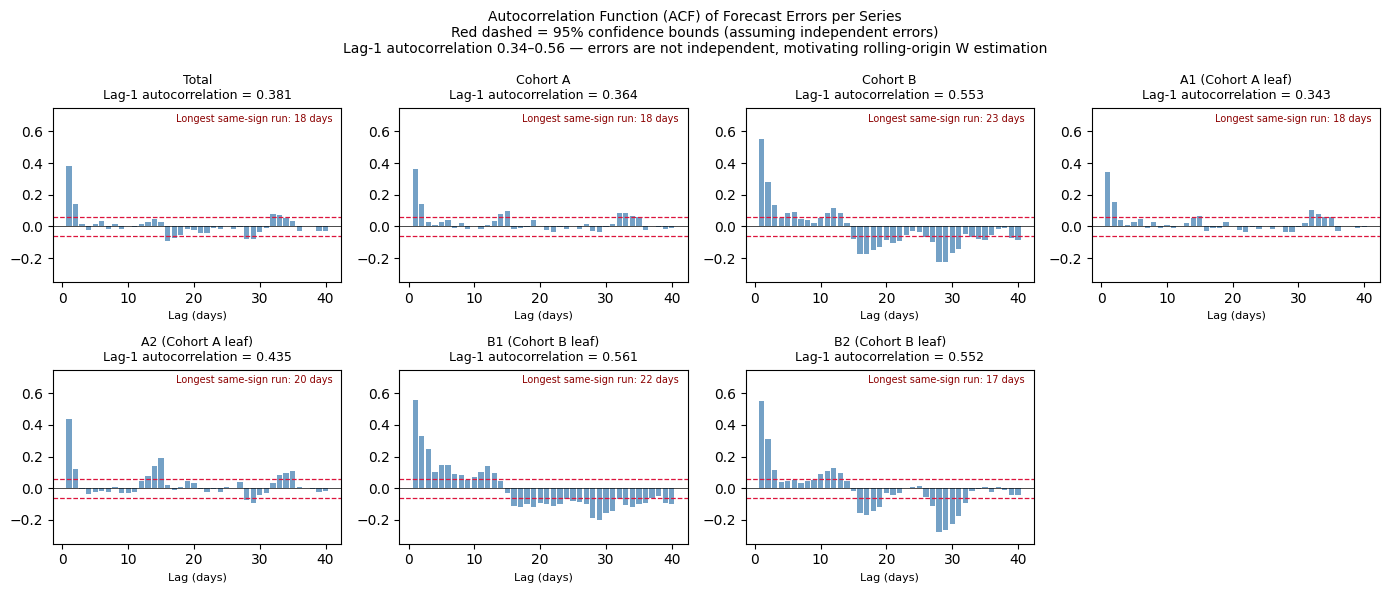

In [7]:
fig = eda.plot_acf(train, save_dir=FIGURES_DIR)
plt.show()

## Figure 6: Forecast-Error Covariance Structure (Correlations, Reliability, Key Pairs)

**Plain English:** Before reconciling, we need to know how much to trust each series and how they move together.  A series with small relative error variance is reliable; the GLS moves it less.  Very high correlations (like Total vs Cohort A = 0.96) mean the two series carry almost the same information.  Mathematically, this produces large negative weights when we invert the covariance matrix, which causes the over-correction seen in the future period.

**Decision defended:** Full 7x7 W (not leaves-only); reliability-weighted reconciliation.  This figure consolidates the original Figure 7 sibling scatter plots into Panel C:
- **Panel A:** 7x7 relative forecast-error correlation heatmap
- **Panel B:** Reliability ranking by relative forecast-error variance (diagonal of C) -- higher = less reliable = moved more
- **Panel C:** Key scatter pairs -- sibling leaves within each cohort, and Total-Cohort A (near-collinear pair driving GLS over-correction)

C:\Users\Deepan\Alo_yoga\retail_forecast\eda.py:587: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


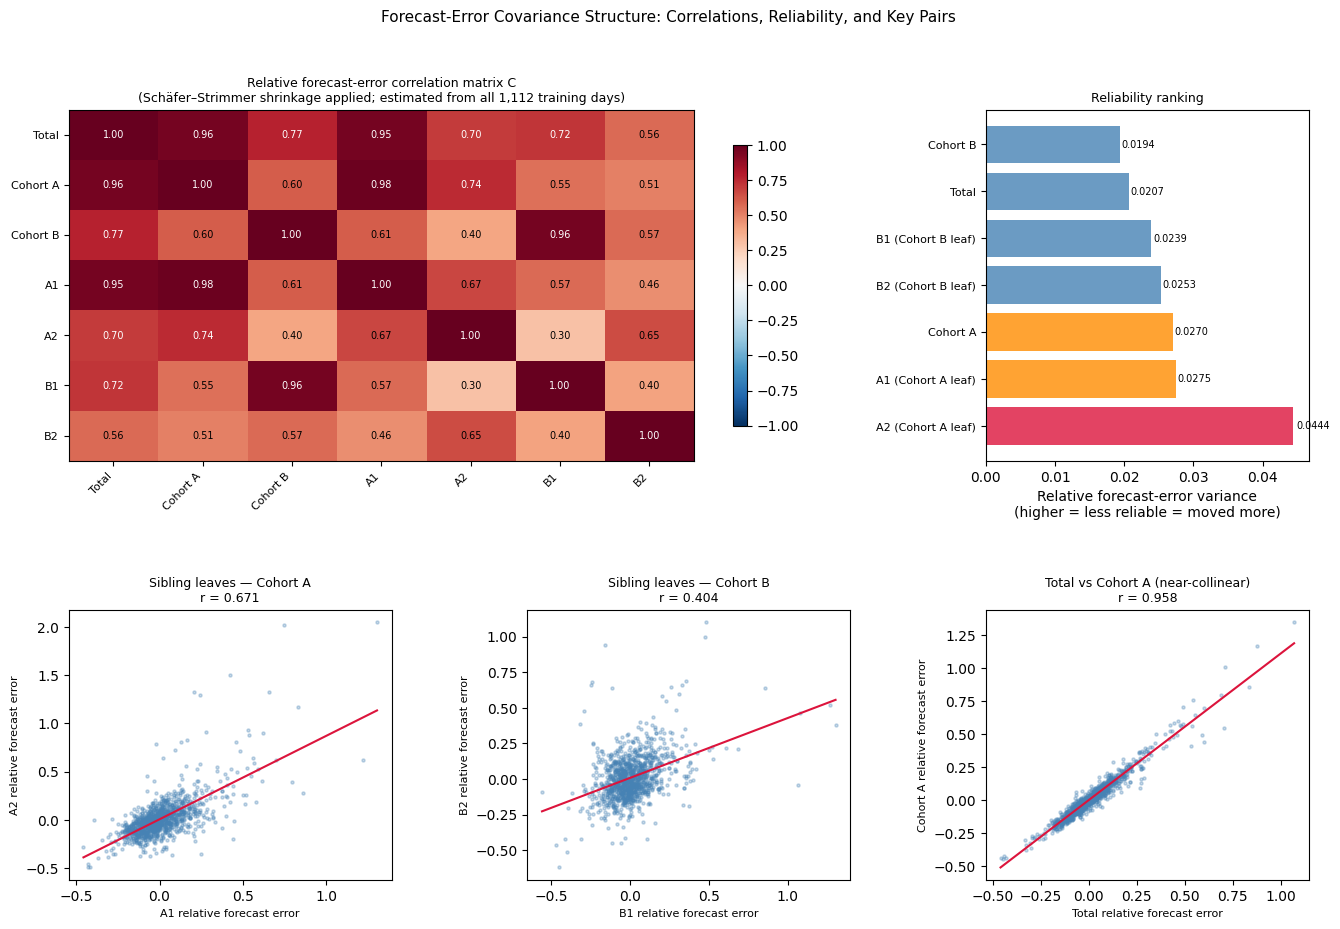

In [8]:
fig = eda.plot_W_structure(C, SERIES, train, save_dir=FIGURES_DIR)
plt.show()

---

## Appendix — Additional Diagnostics

The following two figures are supplementary.  They support decisions documented in the technical memo (Appendix A and B) but are not required to follow the core reconciliation narrative.

## Appendix Figure 8: Residual Non-Gaussianity (QQ Plots)

**Plain English:** The GLS/MinT method is mathematically optimal when forecast errors follow a normal (bell-curve) distribution.  These QQ plots check that assumption.  The tails are heavier than normal — there are more extreme days than a bell curve predicts.  This means the method is approximately correct but may underweight the most extreme forecast days.

**Limitation disclosed:** Heavy tails (excess kurtosis > 0) confirm covariance-based MinT is an approximation; it is statistically consistent but may under-weight tail events.

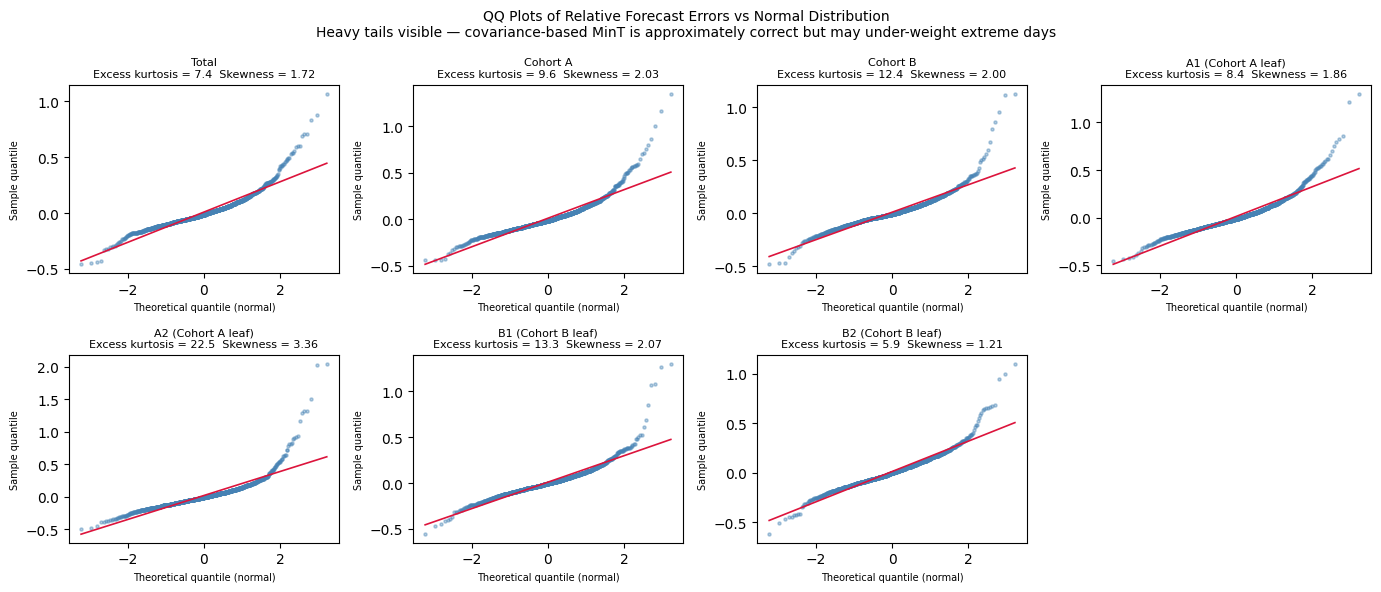

In [9]:
fig = eda.plot_residual_tails(train, save_dir=FIGURES_DIR)
plt.show()

## Appendix Figure 9: Rolling Correlation Stability

**Plain English:** We estimate the error covariance C from all 1,112 training days.  But what if the correlation structure has changed over time?  This figure tracks rolling 180-day correlations for four key series pairs.  They are broadly stable, supporting the use of the full training history for C.

**Decision defended:** Using full-train C for future reconciliation.  Broadly stable rolling correlations mean full-train C has lower estimation variance and is a safe choice.

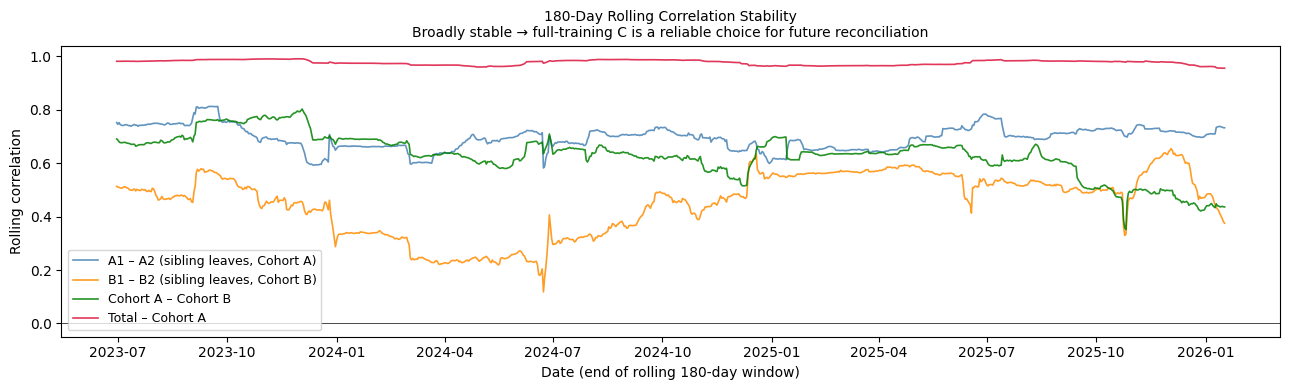

In [10]:
fig = eda.plot_rolling_stability(train, save_dir=FIGURES_DIR)
plt.show()